### Run cells in colab!

In [1]:
# Colab setup: install packages, download ECG data, and show basic usage examples
%pip install -q wfdb numpy matplotlib scipy opencv-python transformers accelerate

from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb

# Download one MIT-BIH Arrhythmia Database record locally in Colab.
# Record 119 contains normal beats and many PVC abnormal beats.
DB_NAME = "mitdb"
RECORD_NAME = "200"
DATA_DIR = Path("/content/mitdb") if Path("/content").exists() else Path("mitdb")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Downloading MIT-BIH record {RECORD_NAME} to {DATA_DIR} ...")
wfdb.dl_database(DB_NAME, dl_dir=str(DATA_DIR), records=[RECORD_NAME])

# Load the local signal and cardiologist annotations.
record_path = str(DATA_DIR / RECORD_NAME)
record = wfdb.rdrecord(record_path)
ann = wfdb.rdann(record_path, "atr")

# ECG signal matrix: shape = (num_samples, num_leads)
ecg = record.p_signal
fs = record.fs

print("\nRecord metadata")
print(f"Record: {RECORD_NAME}")
print(f"Sampling rate: {fs} Hz")
print(f"Signal shape: {ecg.shape} = samples x leads")
print(f"Duration: {ecg.shape[0] / fs / 60:.2f} minutes")
print(f"Lead names: {record.sig_name}")
print(f"Units: {record.units}")

# Beat labels: ann.sample gives the sample index, ann.symbol gives the beat/event label.
label_counts = Counter(ann.symbol)
label_table = pd.DataFrame(label_counts.items(), columns=["symbol", "count"]).sort_values("count", ascending=False)
print("\nAnnotation label counts")
display(label_table)

# For this record, N is normal and V is a PVC abnormal beat.
normal_symbols = {"N"}
annotation_df = pd.DataFrame({
    "sample": ann.sample,
    "time_sec": ann.sample / fs,
    "symbol": ann.symbol,
})
annotation_df["class"] = np.where(annotation_df["symbol"].isin(normal_symbols), "normal", "anomalous")
display(annotation_df.head(10))

def plot_ecg_segment(start_sec=0, duration_sec=10, lead=0):
    """Plot one ECG segment and overlay normal/anomalous beat labels."""
    start = int(start_sec * fs)
    end = int((start_sec + duration_sec) * fs)
    t = np.arange(start, end) / fs

    plt.figure(figsize=(16, 4))
    plt.plot(t, ecg[start:end, lead], color="black", linewidth=1)

    in_window = (ann.sample >= start) & (ann.sample < end)
    for sample, symbol in zip(ann.sample[in_window], np.array(ann.symbol)[in_window]):
        color = "tab:blue" if symbol in normal_symbols else "tab:red"
        plt.axvline(sample / fs, color=color, linestyle="--", alpha=0.65)
        plt.text(sample / fs, plt.ylim()[1] * 0.9, symbol, color=color, ha="center", fontweight="bold")

    plt.title(f"MIT-BIH {RECORD_NAME}, lead {record.sig_name[lead]}: {start_sec}s to {start_sec + duration_sec}s")
    plt.xlabel("Time (seconds)")
    plt.ylabel(f"Amplitude ({record.units[lead]})")
    plt.grid(alpha=0.2)
    plt.show()

# Example 1: plot a short labeled ECG segment.
# plot_ecg_segment(start_sec=110, duration_sec=12, lead=0)

def extract_beat_window(sample, lead=0, before_ms=250, after_ms=450):
    """Return a fixed window around a beat annotation."""
    before = int(before_ms * fs / 1000)
    after = int(after_ms * fs / 1000)
    start = max(sample - before, 0)
    end = min(sample + after, ecg.shape[0])
    x = ecg[start:end, lead]
    t = (np.arange(start, end) - sample) / fs
    return t, x

# Example 2: compare one normal beat against one anomalous/PVC beat.
normal_sample = ann.sample[np.where(np.array(ann.symbol) == "N")[0][0]]
pvc_sample = ann.sample[np.where(np.array(ann.symbol) == "V")[0][0]]

# plt.figure(figsize=(10, 4))
# for sample, label, color in [(normal_sample, "Normal beat (N)", "tab:blue"), (pvc_sample, "PVC anomalous beat (V)", "tab:red")]:
#     t, x = extract_beat_window(sample, lead=0)
#     plt.plot(t, x, label=label, color=color)
# plt.axvline(0, color="gray", linestyle="--", linewidth=1)
# plt.title("Beat-centered examples")
# plt.xlabel("Time from annotation (seconds)")
# plt.ylabel(f"Amplitude ({record.units[0]})")
# plt.legend()
# plt.grid(alpha=0.2)
# plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 111.4 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
Generat

,symbol,count
2,N,1743
1,V,826
0,+,148
4,~,43
3,A,30
5,F,2


,sample,time_sec,symbol,class
0,67,0.186111,+,anomalous
1,225,0.625000,V,anomalous
2,487,1.352778,N,normal
3,689,1.913889,V,anomalous
4,964,2.677778,N,normal
5,1147,3.186111,V,anomalous
6,1433,3.980556,N,normal
7,1610,4.472222,V,anomalous
8,1882,5.227778,N,normal
9,2072,5.755556,V,anomalous


Sequence-wise rhythm segments in this record:


,start_sec,end_sec,duration_sec,rhythm,class
0,0.186111,10.030556,9.844444,(B,not-normal rhythm
1,10.030556,40.136111,30.105556,(N,normal rhythm
2,40.136111,43.780556,3.644444,(B,not-normal rhythm
3,43.780556,45.250000,1.469444,(N,normal rhythm
4,45.250000,51.500000,6.250000,(B,not-normal rhythm
...,...,...,...,...,...
143,1753.075000,1768.305556,15.230556,(N,normal rhythm
144,1768.305556,1773.641667,5.336111,(B,not-normal rhythm
145,1773.641667,1778.713889,5.072222,(N,normal rhythm
146,1778.713889,1784.025000,5.311111,(B,not-normal rhythm


Available rhythm labels: ['(B', '(N', '(VT']


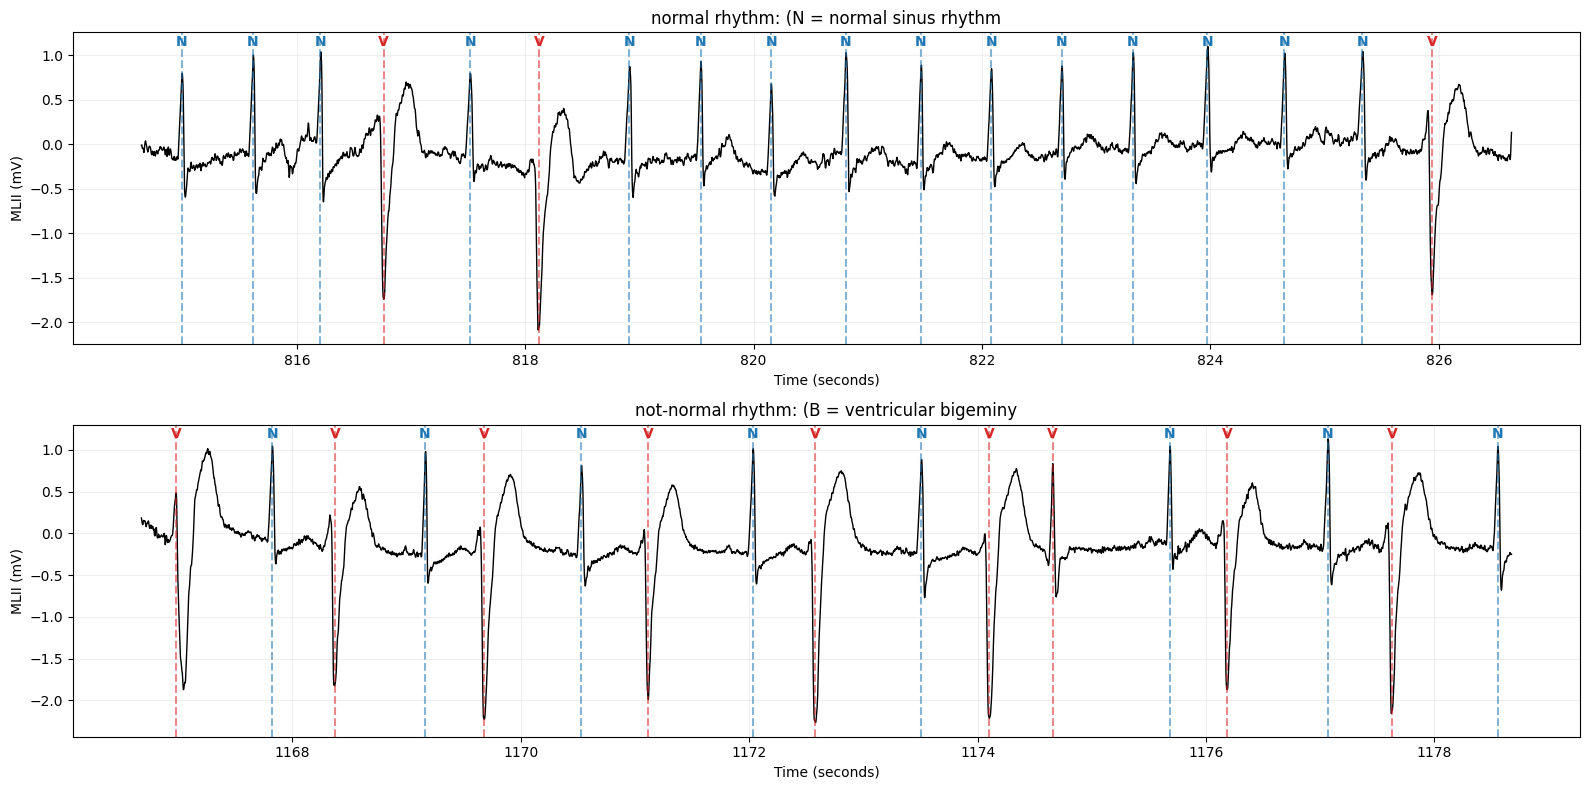

Rhythm labels mark intervals: each rhythm starts at its annotation and continues until the next rhythm annotation.


In [3]:
# Example: sequence-wise rhythm labels from MIT-BIH annotations
# Run the setup cell first so record, ann, ecg, fs, and normal_symbols exist.

def clean_rhythm_label(aux):
    # WFDB rhythm aux notes can include null terminators like "(N\x00".
    return str(aux).replace("\x00", "").strip()

rhythm_rows = []
for sample, aux in zip(ann.sample, ann.aux_note):
    rhythm = clean_rhythm_label(aux)
    if rhythm.startswith("("):
        rhythm_rows.append({
            "start_sample": sample,
            "start_sec": sample / fs,
            "rhythm": rhythm,
        })

rhythm_df = pd.DataFrame(rhythm_rows)
if rhythm_df.empty:
    raise ValueError("No rhythm-level annotations found in ann.aux_note for this record.")

rhythm_df["end_sample"] = rhythm_df["start_sample"].shift(-1, fill_value=ecg.shape[0]).astype(int)
rhythm_df["end_sec"] = rhythm_df["end_sample"] / fs
rhythm_df["duration_sec"] = rhythm_df["end_sec"] - rhythm_df["start_sec"]
rhythm_df["class"] = np.where(rhythm_df["rhythm"].eq("(N"), "normal rhythm", "not-normal rhythm")

print("Sequence-wise rhythm segments in this record:")
display(rhythm_df[["start_sec", "end_sec", "duration_sec", "rhythm", "class"]])
print("Available rhythm labels:", sorted(rhythm_df["rhythm"].unique()))

normal_candidates = rhythm_df[rhythm_df["rhythm"] == "(N"]
abnormal_candidates = rhythm_df[rhythm_df["rhythm"] != "(N"]

if normal_candidates.empty:
    raise ValueError("No explicit (N normal-rhythm segment found after cleaning aux_note labels.")
if abnormal_candidates.empty:
    raise ValueError("No non-(N abnormal rhythm segment found in this record.")

# Pick segments long enough to see several beats, if available.
normal_rhythm = normal_candidates.sort_values("duration_sec", ascending=False).iloc[0]
abnormal_rhythm = abnormal_candidates.sort_values("duration_sec", ascending=False).iloc[0]

rhythm_names = {
    "(N": "normal sinus rhythm",
    "(B": "ventricular bigeminy",
    "(T": "ventricular trigeminy",
    "(VT": "ventricular tachycardia",
    "(AFIB": "atrial fibrillation",
    "(AFL": "atrial flutter",
}

def plot_rhythm_segment(row, duration_sec=12, lead=0):
    start = int(row["start_sample"])
    segment_end = min(int(start + duration_sec * fs), int(row["end_sample"]), ecg.shape[0])
    if segment_end <= start:
        segment_end = min(int(start + duration_sec * fs), ecg.shape[0])

    t = np.arange(start, segment_end) / fs
    plt.plot(t, ecg[start:segment_end, lead], color="black", linewidth=1)

    ann_samples = np.array(ann.sample)
    ann_symbols = np.array(ann.symbol)
    in_window = (ann_samples >= start) & (ann_samples < segment_end)
    for sample, symbol in zip(ann_samples[in_window], ann_symbols[in_window]):
        if symbol == "+":
            continue
        color = "tab:blue" if symbol in normal_symbols else "tab:red"
        plt.axvline(sample / fs, color=color, linestyle="--", alpha=0.55)
        plt.text(sample / fs, plt.ylim()[1] * 0.88, symbol, color=color, ha="center", fontweight="bold")

    rhythm = row["rhythm"]
    readable = rhythm_names.get(rhythm, rhythm)
    plt.title(f"{row['class']}: {rhythm} = {readable}")
    plt.xlabel("Time (seconds)")
    plt.ylabel(f"{record.sig_name[lead]} ({record.units[lead]})")
    plt.grid(alpha=0.2)

plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 1)
plot_rhythm_segment(normal_rhythm, duration_sec=12, lead=0)

plt.subplot(2, 1, 2)
plot_rhythm_segment(abnormal_rhythm, duration_sec=12, lead=0)

plt.tight_layout()
plt.show()

print("Rhythm labels mark intervals: each rhythm starts at its annotation and continues until the next rhythm annotation.")


In [4]:
# Count sequence-wise rhythm labels for the loaded record
# Run the setup cell first. This counts rhythm intervals in ann.aux_note.

def clean_rhythm_label(aux):
    return str(aux).replace("\x00", "").strip()

rhythm_labels = [clean_rhythm_label(aux) for aux in ann.aux_note]
rhythm_labels = [label for label in rhythm_labels if label.startswith("(")]

rhythm_count_df = (
    pd.Series(rhythm_labels, name="rhythm")
    .value_counts()
    .rename_axis("rhythm")
    .reset_index(name="num_segments")
)
rhythm_count_df["class"] = np.where(rhythm_count_df["rhythm"].eq("(N"), "normal rhythm", "not-normal rhythm")

print(f"Total labeled rhythm/sequence segments: {len(rhythm_labels)}")
print(f"Number of unique rhythm labels: {rhythm_count_df['rhythm'].nunique()}")
display(rhythm_count_df)


Total labeled rhythm/sequence segments: 148
Number of unique rhythm labels: 3


,rhythm,num_segments,class
0,(B,71,not-normal rhythm
1,(N,70,normal rhythm
2,(VT,7,not-normal rhythm


Total rhythm segments: 148
Beat-count distribution across all rhythm segments:


,count,mean,std,min,25%,50%,75%,max
num_beats,148.0,17.864865,27.923035,2.0,5.0,9.0,15.25,199.0


Beat-count distribution by rhythm label:


,rhythm,num_segments,min,median,mean,max
0,(B,71,5,9.0,16.873239,165
1,(N,70,2,10.0,20.328571,199
2,(VT,7,3,3.0,3.285714,4


Each rhythm segment with beat counts:


,start_sec,end_sec,duration_sec,rhythm,class,num_beats,num_normal_beats,num_abnormal_beats
0,0.186111,10.030556,9.844444,(B,not-normal rhythm,15,7,8
1,10.030556,40.136111,30.105556,(N,normal rhythm,43,31,12
2,40.136111,43.780556,3.644444,(B,not-normal rhythm,5,2,3
3,43.780556,45.250000,1.469444,(N,normal rhythm,2,2,0
4,45.250000,51.500000,6.250000,(B,not-normal rhythm,9,4,5
...,...,...,...,...,...,...,...,...
143,1753.075000,1768.305556,15.230556,(N,normal rhythm,20,18,2
144,1768.305556,1773.641667,5.336111,(B,not-normal rhythm,7,3,4
145,1773.641667,1778.713889,5.072222,(N,normal rhythm,7,7,0
146,1778.713889,1784.025000,5.311111,(B,not-normal rhythm,7,3,4


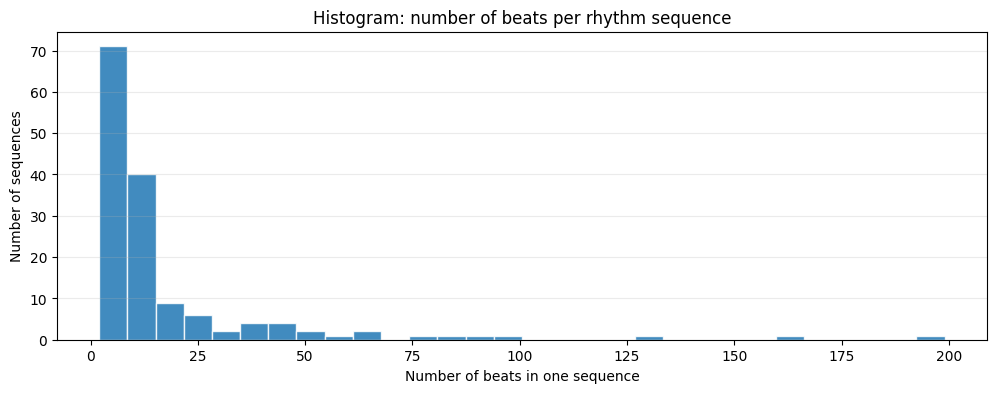

In [5]:
# Distribution: number of beat annotations inside each rhythm/sequence segment
# Run the setup cell first so ann, ecg, fs, and pd/np exist.

def clean_rhythm_label(aux):
    return str(aux).replace("\x00", "").strip()

beat_symbols_to_ignore = {"+"}  # + marks rhythm changes, not actual beat classes

rhythm_rows = []
for sample, aux in zip(ann.sample, ann.aux_note):
    rhythm = clean_rhythm_label(aux)
    if rhythm.startswith("("):
        rhythm_rows.append({
            "start_sample": sample,
            "start_sec": sample / fs,
            "rhythm": rhythm,
        })

segments_df = pd.DataFrame(rhythm_rows)
if segments_df.empty:
    raise ValueError("No rhythm-level segments found in ann.aux_note.")

segments_df["end_sample"] = segments_df["start_sample"].shift(-1, fill_value=ecg.shape[0]).astype(int)
segments_df["end_sec"] = segments_df["end_sample"] / fs
segments_df["duration_sec"] = segments_df["end_sec"] - segments_df["start_sec"]
segments_df["class"] = np.where(segments_df["rhythm"].eq("(N"), "normal rhythm", "not-normal rhythm")

ann_samples = np.array(ann.sample)
ann_symbols = np.array(ann.symbol)

beat_counts = []
normal_beat_counts = []
abnormal_beat_counts = []
for _, row in segments_df.iterrows():
    in_segment = (ann_samples >= row["start_sample"]) & (ann_samples < row["end_sample"])
    segment_symbols = ann_symbols[in_segment]
    beat_symbols = segment_symbols[~np.isin(segment_symbols, list(beat_symbols_to_ignore))]

    beat_counts.append(len(beat_symbols))
    normal_beat_counts.append(np.sum(beat_symbols == "N"))
    abnormal_beat_counts.append(np.sum(beat_symbols != "N"))

segments_df["num_beats"] = beat_counts
segments_df["num_normal_beats"] = normal_beat_counts
segments_df["num_abnormal_beats"] = abnormal_beat_counts

print(f"Total rhythm segments: {len(segments_df)}")
print("Beat-count distribution across all rhythm segments:")
display(segments_df["num_beats"].describe().to_frame().T)

print("Beat-count distribution by rhythm label:")
summary_by_rhythm = (
    segments_df
    .groupby("rhythm")["num_beats"]
    .agg(num_segments="count", min="min", median="median", mean="mean", max="max")
    .reset_index()
)
display(summary_by_rhythm)

print("Each rhythm segment with beat counts:")
display(segments_df[[
    "start_sec", "end_sec", "duration_sec", "rhythm", "class",
    "num_beats", "num_normal_beats", "num_abnormal_beats"
]])

# Histogram: how many beats are in one rhythm/sequence segment.
plt.figure(figsize=(12, 4))
plt.hist(
    segments_df["num_beats"],
    bins=30,
    color="tab:blue",
    edgecolor="white",
    alpha=0.85,
)
plt.title("Histogram: number of beats per rhythm sequence")
plt.xlabel("Number of beats in one sequence")
plt.ylabel("Number of sequences")
plt.grid(axis="y", alpha=0.25)
plt.show()




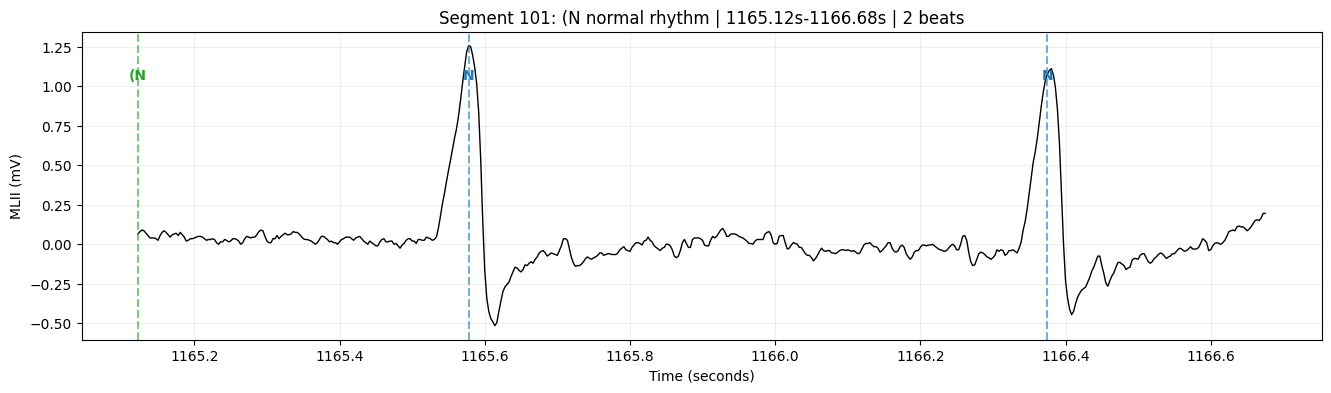

In [6]:
# Function: plot one labeled rhythm/sequence segment
# Run the setup cell and the beats-per-rhythm-segment cell first so segments_df exists.

def plot_labeled_segment(segment, lead=0, max_duration_sec=None, show_aux=True):
    """
    Plot one rhythm segment with beat labels.

    segment can be either:
    - an integer row index into segments_df
    - a pandas Series row from segments_df.iloc[i]
    """
    if isinstance(segment, int):
        row = segments_df.iloc[segment]
    else:
        row = segment

    start = int(row["start_sample"])
    end = int(row["end_sample"])
    if max_duration_sec is not None:
        end = min(end, start + int(max_duration_sec * fs))
    end = min(end, ecg.shape[0])

    t = np.arange(start, end) / fs
    y = ecg[start:end, lead]

    ann_samples = np.array(ann.sample)
    ann_symbols = np.array(ann.symbol)
    ann_aux = np.array([str(x).replace("\x00", "").strip() for x in ann.aux_note])
    in_segment = (ann_samples >= start) & (ann_samples < end)

    plt.figure(figsize=(16, 4))
    plt.plot(t, y, color="black", linewidth=1)

    y_top = np.max(y)
    y_bottom = np.min(y)
    label_y = y_top - 0.08 * (y_top - y_bottom)

    for sample, symbol, aux in zip(ann_samples[in_segment], ann_symbols[in_segment], ann_aux[in_segment]):
        if symbol == "+":
            color = "tab:green"
            label = aux if show_aux and aux else "+"
        else:
            color = "tab:blue" if symbol in normal_symbols else "tab:red"
            label = symbol

        plt.axvline(sample / fs, color=color, linestyle="--", alpha=0.6)
        plt.text(sample / fs, label_y, label, color=color, ha="center", va="top", fontweight="bold")

    rhythm = row.get("rhythm", "unknown")
    segment_class = row.get("class", "")
    num_beats = row.get("num_beats", "?")
    plt.title(
        f"Segment {row.name}: {rhythm} {segment_class} | "
        f"{row['start_sec']:.2f}s-{row['end_sec']:.2f}s | {num_beats} beats"
    )
    plt.xlabel("Time (seconds)")
    plt.ylabel(f"{record.sig_name[lead]} ({record.units[lead]})")
    plt.grid(alpha=0.2)
    plt.show()

# Example: plot the first segment. Change 0 to any row index in segments_df.
plot_labeled_segment(101, lead=0, max_duration_sec=15)


In [7]:
segments_df

,start_sample,start_sec,rhythm,end_sample,end_sec,duration_sec,class,num_beats,num_normal_beats,num_abnormal_beats
0,67,0.186111,(B,3611,10.030556,9.844444,not-normal rhythm,15,7,8
1,3611,10.030556,(N,14449,40.136111,30.105556,normal rhythm,43,31,12
2,14449,40.136111,(B,15761,43.780556,3.644444,not-normal rhythm,5,2,3
3,15761,43.780556,(N,16290,45.250000,1.469444,normal rhythm,2,2,0
4,16290,45.250000,(B,18540,51.500000,6.250000,not-normal rhythm,9,4,5
...,...,...,...,...,...,...,...,...,...,...
143,631107,1753.075000,(N,636590,1768.305556,15.230556,normal rhythm,20,18,2
144,636590,1768.305556,(B,638511,1773.641667,5.336111,not-normal rhythm,7,3,4
145,638511,1773.641667,(N,640337,1778.713889,5.072222,normal rhythm,7,7,0
146,640337,1778.713889,(B,642249,1784.025000,5.311111,not-normal rhythm,7,3,4


Beat label counts:


,symbol,count
0,N,1743
1,V,826
2,A,30
3,F,2


Normal beat metadata: {'beat_index': 1, 'beat_sample': 487, 'beat_time_sec': 1.3527777777777779, 'symbol': 'N', 'class': 'normal beat', 'rhythm': '(B', 'lead': 'MLII', 'start_sample': 307, 'end_sample': 811, 'before_ms': 500, 'after_ms': 900, 'beat_position_fraction': 0.35714285714285715, 'frames_shape': (16, 224, 224, 3)}
Anomalous beat metadata: {'beat_index': 0, 'beat_sample': 225, 'beat_time_sec': 0.625, 'symbol': 'V', 'class': 'anomalous beat', 'rhythm': '(B', 'lead': 'MLII', 'start_sample': 45, 'end_sample': 549, 'before_ms': 500, 'after_ms': 900, 'beat_position_fraction': 0.35714285714285715, 'frames_shape': (16, 224, 224, 3)}
Frame dtype/shape: uint8 (16, 224, 224, 3)


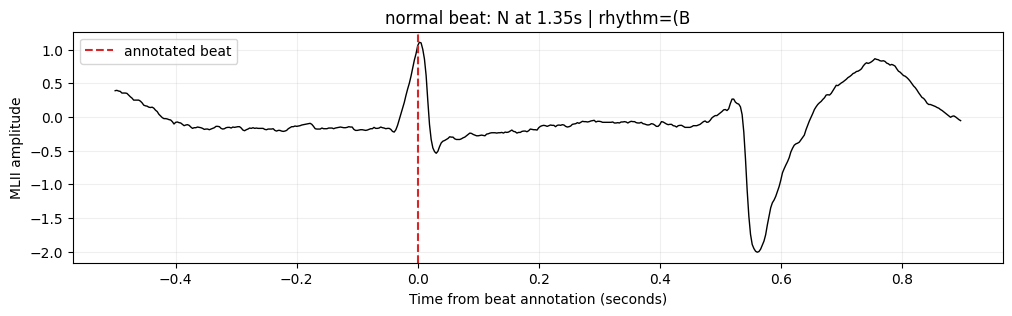

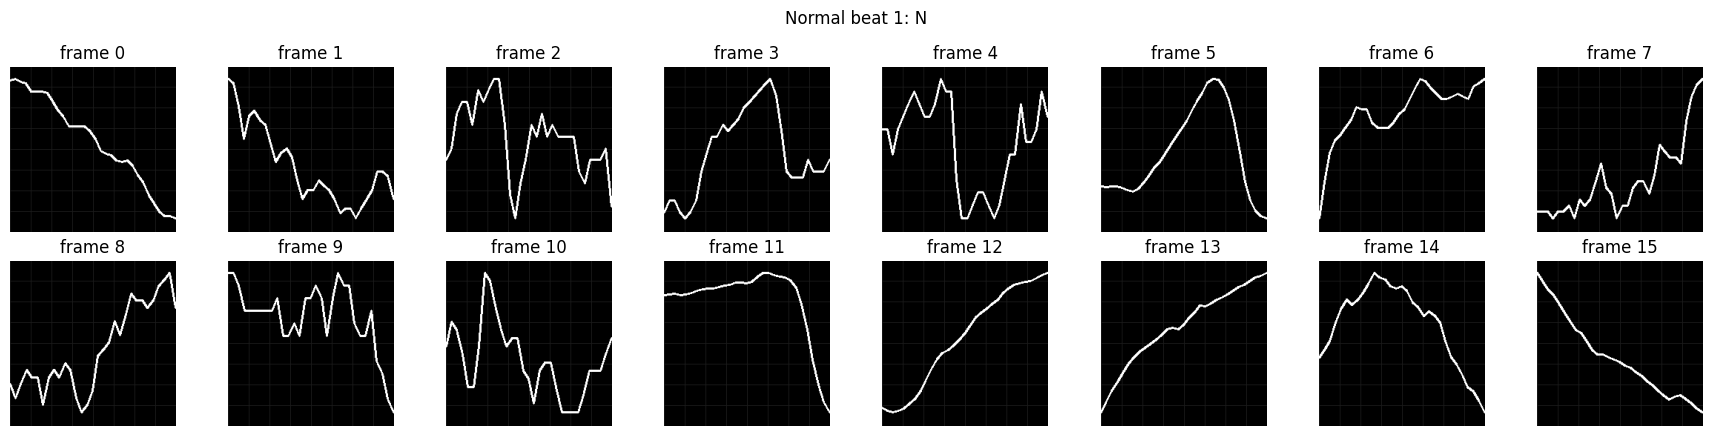

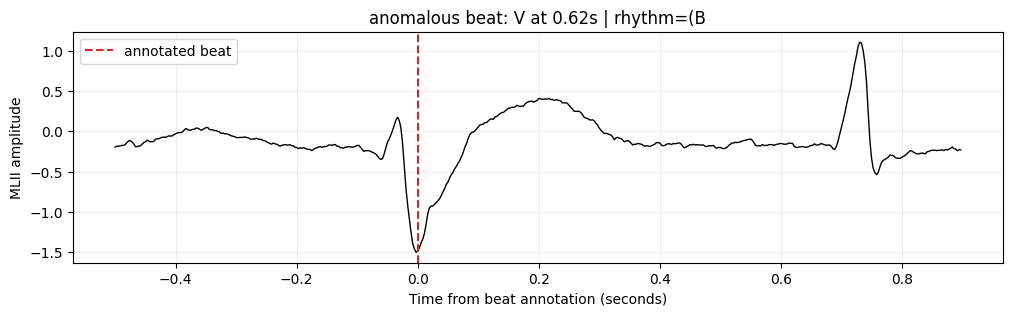

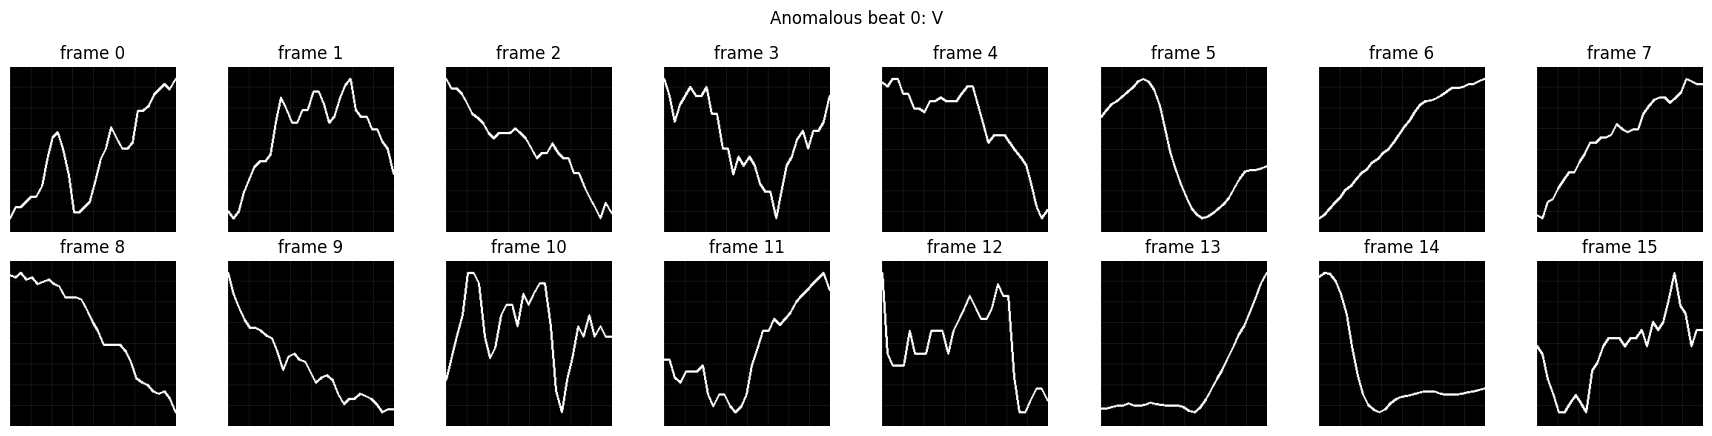

In [8]:
# Pipeline: annotated ECG beat -> beat-centered window -> V-JEPA-style video frames
# Run the setup cell first so record, ann, ecg, fs, and normal_symbols exist.

%pip install -q opencv-python

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NON_BEAT_SYMBOLS = {"+", "~", "|", "x"}

def clean_aux_note(aux):
    return str(aux).replace("\x00", "").strip()

def build_beat_df():
    """Create one row per beat annotation, excluding rhythm-change/non-beat markers."""
    rows = []
    current_rhythm = None

    for sample, symbol, aux in zip(ann.sample, ann.symbol, ann.aux_note):
        aux_clean = clean_aux_note(aux)
        if aux_clean.startswith("("):
            current_rhythm = aux_clean

        if symbol in NON_BEAT_SYMBOLS:
            continue

        rows.append({
            "sample": int(sample),
            "time_sec": float(sample / fs),
            "symbol": symbol,
            "class": "normal beat" if symbol in normal_symbols else "anomalous beat",
            "rhythm": current_rhythm,
        })

    return pd.DataFrame(rows)

def extract_beat_centered_window(beat, lead=0, before_ms=500, after_ms=900):
    """
    Extract a fixed ECG window centered around one beat annotation.

    beat can be either:
    - an integer row index into beat_df
    - a pandas Series row from beat_df.iloc[i]

    The output always has the same length by edge-padding near record boundaries.
    """
    row = beat_df.iloc[int(beat)] if isinstance(beat, (int, np.integer)) else beat

    beat_sample = int(row["sample"])
    before = int(round(before_ms * fs / 1000))
    after = int(round(after_ms * fs / 1000))
    window_len = before + after

    start = beat_sample - before
    end = beat_sample + after

    src_start = max(start, 0)
    src_end = min(end, ecg.shape[0])
    signal = ecg[src_start:src_end, lead].astype(np.float32)

    pad_left = src_start - start
    pad_right = end - src_end
    if pad_left or pad_right:
        signal = np.pad(signal, (pad_left, pad_right), mode="edge")

    meta = {
        "beat_index": int(row.name),
        "beat_sample": beat_sample,
        "beat_time_sec": float(beat_sample / fs),
        "symbol": row["symbol"],
        "class": row["class"],
        "rhythm": row.get("rhythm", None),
        "lead": record.sig_name[lead],
        "start_sample": int(start),
        "end_sample": int(end),
        "before_ms": before_ms,
        "after_ms": after_ms,
        "beat_position_fraction": before / window_len,
    }
    return signal, meta

def ecg_window_to_vjepa_frames(signal, num_frames=16, image_size=224, pad=18, line_thickness=2, draw_grid=True):
    """
    Render a beat-centered ECG window as V-JEPA-compatible RGB video frames.

    Returns uint8 frames with shape: (num_frames, image_size, image_size, 3).
    Do not draw labels/beat markers into these frames; they are model input.
    """
    signal = np.asarray(signal, dtype=np.float32)
    signal = (signal - signal.mean()) / (signal.std() + 1e-6)
    chunks = np.array_split(signal, num_frames)

    frames = []
    for chunk in chunks:
        frame = np.zeros((image_size, image_size, 3), dtype=np.uint8)

        if draw_grid:
            for x in range(0, image_size, 28):
                cv2.line(frame, (x, 0), (x, image_size - 1), (28, 28, 28), 1)
            for y in range(0, image_size, 28):
                cv2.line(frame, (0, y), (image_size - 1, y), (28, 28, 28), 1)

        x_pts = np.linspace(0, image_size - 1, len(chunk)).astype(np.int32)
        y_norm = (chunk - chunk.min()) / (chunk.max() - chunk.min() + 1e-6)
        y_pts = (image_size - 1 - (y_norm * (image_size - 2 * pad) + pad)).astype(np.int32)
        pts = np.column_stack([x_pts, y_pts]).astype(np.int32)
        cv2.polylines(frame, [pts], isClosed=False, color=(255, 255, 255), thickness=line_thickness)
        frames.append(frame)

    return np.stack(frames, axis=0)

def beat_to_vjepa_frames(beat, lead=0, before_ms=500, after_ms=900, num_frames=16, image_size=224):
    signal, meta = extract_beat_centered_window(
        beat,
        lead=lead,
        before_ms=before_ms,
        after_ms=after_ms,
    )
    frames = ecg_window_to_vjepa_frames(
        signal,
        num_frames=num_frames,
        image_size=image_size,
    )
    meta["frames_shape"] = frames.shape
    return frames, signal, meta

def plot_beat_window(signal, meta):
    t = (np.arange(len(signal)) / fs) - (meta["before_ms"] / 1000)
    plt.figure(figsize=(12, 3))
    plt.plot(t, signal, color="black", linewidth=1)
    plt.axvline(0, color="tab:red", linestyle="--", label="annotated beat")
    plt.title(f"{meta['class']}: {meta['symbol']} at {meta['beat_time_sec']:.2f}s | rhythm={meta['rhythm']}")
    plt.xlabel("Time from beat annotation (seconds)")
    plt.ylabel(f"{meta['lead']} amplitude")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

def show_vjepa_frames(frames, title="Beat-centered V-JEPA frames", max_frames=16):
    n = min(len(frames), max_frames)
    cols = min(8, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(2.2 * cols, 2.2 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(frames[i])
        plt.title(f"frame {i}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

beat_df = build_beat_df()
print("Beat label counts:")
display(beat_df["symbol"].value_counts().rename_axis("symbol").reset_index(name="count"))

normal_beat_idx = beat_df[beat_df["class"] == "normal beat"].index[0]
anomaly_beat_idx = beat_df[beat_df["class"] == "anomalous beat"].index[0]

normal_frames, normal_signal, normal_meta = beat_to_vjepa_frames(normal_beat_idx, lead=0)
anomaly_frames, anomaly_signal, anomaly_meta = beat_to_vjepa_frames(anomaly_beat_idx, lead=0)

print("Normal beat metadata:", normal_meta)
print("Anomalous beat metadata:", anomaly_meta)
print("Frame dtype/shape:", normal_frames.dtype, normal_frames.shape)

plot_beat_window(normal_signal, normal_meta)
show_vjepa_frames(normal_frames, title=f"Normal beat {normal_beat_idx}: {normal_meta['symbol']}")

plot_beat_window(anomaly_signal, anomaly_meta)
show_vjepa_frames(anomaly_frames, title=f"Anomalous beat {anomaly_beat_idx}: {anomaly_meta['symbol']}")

# Later, feed beat-centered frames to Hugging Face V-JEPA like this:
# inputs = processor([normal_frames, anomaly_frames], return_tensors="pt").to(device)
# with torch.no_grad():
#     outputs = model(**inputs)
# embeddings = outputs.last_hidden_state[:, 0, :]  # one embedding per beat-centered ECG window


Normal sequence metadata: {'segment_id': 33, 'rhythm': '(N', 'class': 'normal rhythm', 'start_sample': 144759, 'end_sample': 146354, 'start_sec': 402.10833333333335, 'end_sec': 406.5388888888889, 'duration_sec': 4.430555555555555, 'lead': 'MLII', 'num_samples': 1595, 'num_beats': 6, 'num_normal_beats': 6, 'num_abnormal_beats': 0, 'frames_shape': (5, 224, 224, 3), 'num_frames': 5, 'seconds_per_frame': 1, 'samples_per_frame': 360, 'valid_samples_per_frame': [360, 360, 360, 360, 155], 'global_min': -0.5899999737739563, 'global_max': 1.2899999618530273}
Anomalous sequence metadata: {'segment_id': 96, 'rhythm': '(B', 'class': 'not-normal rhythm', 'start_sample': 405554, 'end_sample': 408085, 'start_sec': 1126.5388888888888, 'end_sec': 1133.5694444444443, 'duration_sec': 7.030555555555556, 'lead': 'MLII', 'num_samples': 2531, 'num_beats': 10, 'num_normal_beats': 5, 'num_abnormal_beats': 5, 'frames_shape': (8, 224, 224, 3), 'num_frames': 8, 'seconds_per_frame': 1, 'samples_per_frame': 360, 'v

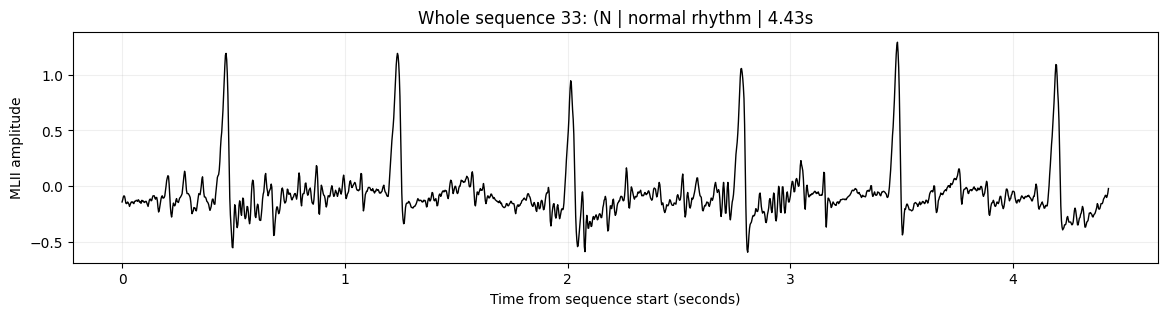

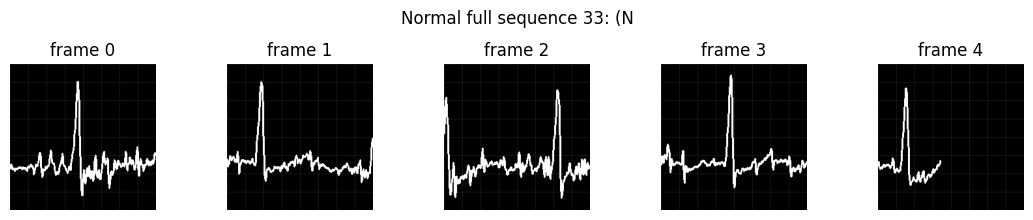

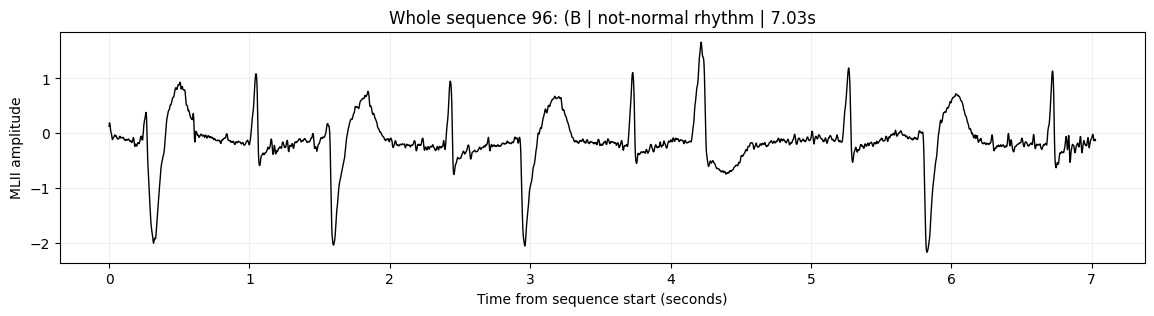

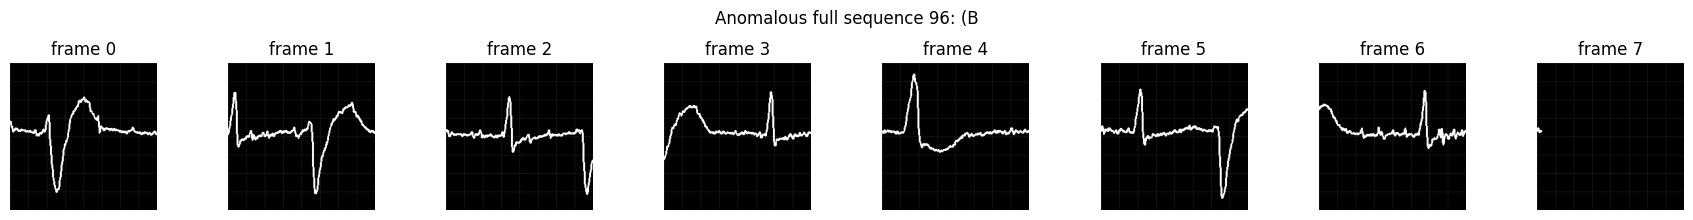

In [9]:
# Pipeline: whole rhythm sequence -> time-scaled V-JEPA-style video frames
# Run the setup cell and the segments_df cell first.

%pip install -q opencv-python

import cv2
import matplotlib.pyplot as plt
import numpy as np


def extract_whole_sequence(segment, lead=0, max_duration_sec=None):
    """
    Extract the full ECG signal for one rhythm/sequence segment.

    segment can be either:
    - an integer row label/index in segments_df
    - a pandas Series row from segments_df.loc[i]

    If max_duration_sec is set, only the first max_duration_sec seconds are used.
    """
    row = segments_df.loc[segment] if isinstance(segment, (int, np.integer)) else segment

    start = int(row["start_sample"])
    end = int(row["end_sample"])
    if max_duration_sec is not None:
        end = min(end, start + int(round(max_duration_sec * fs)))
    end = min(end, ecg.shape[0])

    signal = ecg[start:end, lead].astype(np.float32)
    if len(signal) == 0:
        raise ValueError("Selected sequence contains no ECG samples.")

    meta = {
        "segment_id": int(row.name),
        "rhythm": row.get("rhythm", "unknown"),
        "class": row.get("class", "unknown"),
        "start_sample": start,
        "end_sample": end,
        "start_sec": start / fs,
        "end_sec": end / fs,
        "duration_sec": (end - start) / fs,
        "lead": record.sig_name[lead],
        "num_samples": len(signal),
    }
    for col in ["num_beats", "num_normal_beats", "num_abnormal_beats"]:
        if col in row:
            meta[col] = int(row[col])
    return signal, meta


def render_ecg_chunk_global_scale(
    chunk,
    global_min,
    global_max,
    expected_num_samples,
    image_size=224,
    pad=18,
    line_thickness=2,
    draw_grid=True,
):
    """
    Render one ECG frame using the same y-axis and x-axis scale for every frame.

    This preserves relative amplitude across frames and preserves time scale in
    the final partial frame. Missing samples are left as blank pixels on the
    right side of the image, not padded as a flatline.
    """
    frame = np.zeros((image_size, image_size, 3), dtype=np.uint8)

    if draw_grid:
        for x in range(0, image_size, 28):
            cv2.line(frame, (x, 0), (x, image_size - 1), (28, 28, 28), 1)
        for y in range(0, image_size, 28):
            cv2.line(frame, (0, y), (image_size - 1, y), (28, 28, 28), 1)

    chunk = np.asarray(chunk, dtype=np.float32)
    if len(chunk) < 2:
        return frame

    full_x = np.linspace(0, image_size - 1, expected_num_samples).astype(np.int32)
    x_pts = full_x[:len(chunk)]
    y_norm = (chunk - global_min) / (global_max - global_min + 1e-6)
    y_norm = np.clip(y_norm, 0.0, 1.0)
    y_pts = (image_size - 1 - (y_norm * (image_size - 2 * pad) + pad)).astype(np.int32)
    pts = np.column_stack([x_pts, y_pts]).astype(np.int32)
    cv2.polylines(frame, [pts], isClosed=False, color=(255, 255, 255), thickness=line_thickness)
    return frame


def whole_sequence_to_time_windowed_frames(
    segment,
    lead=0,
    seconds_per_frame=0.5,
    image_size=224,
    max_duration_sec=None,
):
    """
    Convert one full rhythm sequence into frames with constant ECG time per frame.

    Longer sequences produce more frames:
        num_frames = ceil(duration_sec / seconds_per_frame)

    All frames use global min/max scaling from the whole sequence, so amplitude
    is comparable across frames in the same sequence.
    """
    signal, meta = extract_whole_sequence(segment, lead=lead, max_duration_sec=max_duration_sec)

    samples_per_frame = max(2, int(round(seconds_per_frame * fs)))
    num_frames = int(np.ceil(len(signal) / samples_per_frame))
    global_min = float(np.min(signal))
    global_max = float(np.max(signal))

    frames = []
    valid_samples_per_frame = []
    for i in range(num_frames):
        start = i * samples_per_frame
        end = min(start + samples_per_frame, len(signal))
        chunk = signal[start:end]
        valid_samples_per_frame.append(int(len(chunk)))
        frame = render_ecg_chunk_global_scale(
            chunk,
            global_min=global_min,
            global_max=global_max,
            expected_num_samples=samples_per_frame,
            image_size=image_size,
        )
        frames.append(frame)

    frames = np.stack(frames, axis=0)

    meta["frames_shape"] = frames.shape
    meta["num_frames"] = num_frames
    meta["seconds_per_frame"] = seconds_per_frame
    meta["samples_per_frame"] = samples_per_frame
    meta["valid_samples_per_frame"] = valid_samples_per_frame
    meta["global_min"] = global_min
    meta["global_max"] = global_max
    return frames, signal, meta


def plot_whole_sequence_signal(signal, meta):
    t = np.arange(len(signal)) / fs
    plt.figure(figsize=(14, 3))
    plt.plot(t, signal, color="black", linewidth=1)
    plt.title(
        f"Whole sequence {meta['segment_id']}: {meta['rhythm']} | "
        f"{meta['class']} | {meta['duration_sec']:.2f}s"
    )
    plt.xlabel("Time from sequence start (seconds)")
    plt.ylabel(f"{meta['lead']} amplitude")
    plt.grid(alpha=0.2)
    plt.show()


def show_sequence_frames(frames, title="Whole sequence as time-windowed frames", max_frames=32):
    n = min(len(frames), max_frames)
    cols = min(8, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(2.2 * cols, 2.2 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(frames[i])
        plt.title(f"frame {i}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Example: one full normal sequence and one full anomalous sequence.
# Each frame captures this many seconds of ECG. Longer sequences produce more frames.
SECONDS_PER_FRAME = 1
# sample random index from each class if there are multiple segments, or just take the only segment if there's one.
normal_sequence_idx = segments_df[segments_df["class"] == "normal rhythm"].index[np.random.randint(0, len(segments_df[segments_df["class"] == "normal rhythm"]))]
anomaly_sequence_idx = segments_df[segments_df["class"] != "normal rhythm"].index[np.random.randint(0, len(segments_df[segments_df["class"] != "normal rhythm"]))]

normal_seq_frames, normal_seq_signal, normal_seq_meta = whole_sequence_to_time_windowed_frames(
    normal_sequence_idx,
    lead=0,
    seconds_per_frame=SECONDS_PER_FRAME,
    image_size=224,
)
anomaly_seq_frames, anomaly_seq_signal, anomaly_seq_meta = whole_sequence_to_time_windowed_frames(
    anomaly_sequence_idx,
    lead=0,
    seconds_per_frame=SECONDS_PER_FRAME,
    image_size=224,
)

print("Normal sequence metadata:", normal_seq_meta)
print("Anomalous sequence metadata:", anomaly_seq_meta)
print("Normal frame dtype/shape:", normal_seq_frames.dtype, normal_seq_frames.shape)
print("Anomalous frame dtype/shape:", anomaly_seq_frames.dtype, anomaly_seq_frames.shape)

plot_whole_sequence_signal(normal_seq_signal, normal_seq_meta)
show_sequence_frames(normal_seq_frames, title=f"Normal full sequence {normal_sequence_idx}: {normal_seq_meta['rhythm']}")

plot_whole_sequence_signal(anomaly_seq_signal, anomaly_seq_meta)
show_sequence_frames(anomaly_seq_frames, title=f"Anomalous full sequence {anomaly_sequence_idx}: {anomaly_seq_meta['rhythm']}")

# Feed to V-JEPA later.
# If your V-JEPA checkpoint requires exactly 16 frames, sample 16-frame clips
# from these time-windowed frame streams instead of passing long videos directly.
# inputs = processor([normal_seq_frames[:16], anomaly_seq_frames[:16]], return_tensors="pt").to(device)
# with torch.no_grad():
#     outputs = model(**inputs)
# embeddings = outputs.last_hidden_state[:, 0, :]


In [17]:
# Multi-record experiment: MIT-BIH rhythm segments -> V-JEPA embeddings -> class separability
%pip install -q -U 'transformers>=4.57.3' scikit-learn

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wfdb
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from transformers import AutoModel, AutoVideoProcessor

DB_NAME = 'mitdb'
RECORD_NAMES = ['100', '106', '108', '200', '202']
DATA_DIR = Path('/content/mitdb_multi') if Path('/content').exists() else Path('mitdb_multi')
DATA_DIR.mkdir(parents=True, exist_ok=True)

LEAD = 0
SECONDS_PER_FRAME = 0.25
IMAGE_SIZE = 256
TARGET_NUM_FRAMES = 16
CLIP_STRIDE = 8
NORMAL_RHYTHMS = {'(N'}
IGNORE_BEAT_SYMBOLS = {'+'}
MODEL_NAME = 'facebook/vjepa2-vitl-fpc64-256'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch_dtype = torch.float16 if device == 'cuda' else torch.float32
batch_size = 2 if device == 'cuda' else 1

print(f'Using device: {device}')
print(f'Downloading records: {RECORD_NAMES}')
wfdb.dl_database(DB_NAME, dl_dir=str(DATA_DIR), records=RECORD_NAMES)


def clean_aux_note(aux):
    return str(aux).replace('\\x00', '').strip()


def build_segments_for_record(record_name, lead=0, max_duration_sec=None):
    record_path = str(DATA_DIR / record_name)
    record = wfdb.rdrecord(record_path)
    ann = wfdb.rdann(record_path, 'atr')
    ecg = record.p_signal
    fs = float(record.fs)

    rhythm_rows = []
    for sample, aux in zip(ann.sample, ann.aux_note):
        rhythm = clean_aux_note(aux)
        if rhythm.startswith('('):
            rhythm_rows.append({
                'start_sample': int(sample),
                'start_sec': float(sample / fs),
                'rhythm': rhythm,
            })

    if not rhythm_rows:
        return pd.DataFrame(), record, ann, ecg, fs

    segments_df = pd.DataFrame(rhythm_rows)
    segments_df['end_sample'] = segments_df['start_sample'].shift(-1, fill_value=ecg.shape[0]).astype(int)
    segments_df['end_sec'] = segments_df['end_sample'] / fs
    segments_df['duration_sec'] = segments_df['end_sec'] - segments_df['start_sec']
    segments_df['class'] = np.where(segments_df['rhythm'].isin(NORMAL_RHYTHMS), 'normal rhythm', 'not-normal rhythm')
    segments_df['record_name'] = record_name
    segments_df['lead_index'] = lead
    segments_df['lead_name'] = record.sig_name[lead]

    ann_samples = np.asarray(ann.sample)
    ann_symbols = np.asarray(ann.symbol)
    beat_counts = []
    normal_counts = []
    abnormal_counts = []
    for _, row in segments_df.iterrows():
        in_segment = (ann_samples >= row['start_sample']) & (ann_samples < row['end_sample'])
        segment_symbols = ann_symbols[in_segment]
        beat_symbols = segment_symbols[~np.isin(segment_symbols, list(IGNORE_BEAT_SYMBOLS))]
        beat_counts.append(int(len(beat_symbols)))
        normal_counts.append(int(np.sum(beat_symbols == 'N')))
        abnormal_counts.append(int(np.sum(beat_symbols != 'N')))

    segments_df['num_beats'] = beat_counts
    segments_df['num_normal_beats'] = normal_counts
    segments_df['num_abnormal_beats'] = abnormal_counts

    if max_duration_sec is not None:
        max_samples = int(round(max_duration_sec * fs))
        segments_df['end_sample'] = np.minimum(segments_df['end_sample'], segments_df['start_sample'] + max_samples)
        segments_df['end_sec'] = segments_df['end_sample'] / fs
        segments_df['duration_sec'] = segments_df['end_sec'] - segments_df['start_sec']

    return segments_df, record, ann, ecg, fs


def render_ecg_chunk_global_scale(chunk, global_min, global_max, expected_num_samples, image_size=256, pad=18, line_thickness=2, draw_grid=True):
    frame = np.zeros((image_size, image_size, 3), dtype=np.uint8)

    if draw_grid:
        for x in range(0, image_size, 32):
            cv2.line(frame, (x, 0), (x, image_size - 1), (28, 28, 28), 1)
        for y in range(0, image_size, 32):
            cv2.line(frame, (0, y), (image_size - 1, y), (28, 28, 28), 1)

    chunk = np.asarray(chunk, dtype=np.float32)
    if len(chunk) < 2:
        return frame

    full_x = np.linspace(0, image_size - 1, expected_num_samples).astype(np.int32)
    x_pts = full_x[:len(chunk)]
    y_norm = (chunk - global_min) / (global_max - global_min + 1e-6)
    y_norm = np.clip(y_norm, 0.0, 1.0)
    y_pts = (image_size - 1 - (y_norm * (image_size - 36) + 18)).astype(np.int32)
    pts = np.column_stack([x_pts, y_pts]).astype(np.int32)
    cv2.polylines(frame, [pts], isClosed=False, color=(255, 255, 255), thickness=line_thickness)
    return frame


def segment_to_frames(ecg, fs, record, segment_row, seconds_per_frame=0.25, image_size=256, lead=0):
    start = int(segment_row['start_sample'])
    end = int(segment_row['end_sample'])
    signal = ecg[start:end, lead].astype(np.float32)
    if len(signal) == 0:
        raise ValueError('Selected segment contains no ECG samples.')

    samples_per_frame = max(2, int(round(seconds_per_frame * fs)))
    num_frames = int(np.ceil(len(signal) / samples_per_frame))
    global_min = float(signal.min())
    global_max = float(signal.max())

    frames = []
    valid_samples_per_frame = []
    for frame_idx in range(num_frames):
        chunk_start = frame_idx * samples_per_frame
        chunk_end = min(chunk_start + samples_per_frame, len(signal))
        chunk = signal[chunk_start:chunk_end]
        valid_samples_per_frame.append(int(len(chunk)))
        frames.append(
            render_ecg_chunk_global_scale(
                chunk,
                global_min=global_min,
                global_max=global_max,
                expected_num_samples=samples_per_frame,
                image_size=image_size,
            )
        )

    meta = {
        'record_name': segment_row['record_name'],
        'rhythm': segment_row['rhythm'],
        'class': segment_row['class'],
        'start_sec': float(segment_row['start_sec']),
        'end_sec': float(segment_row['end_sec']),
        'duration_sec': float(segment_row['duration_sec']),
        'lead_name': record.sig_name[lead],
        'num_frames': num_frames,
        'valid_samples_per_frame': valid_samples_per_frame,
    }
    return np.stack(frames, axis=0), signal, meta


def build_fixed_length_clips(frames, target_num_frames=16, stride=8):
    num_frames = len(frames)
    if num_frames == 0:
        raise ValueError('Cannot build clips from an empty frame sequence.')

    if num_frames <= target_num_frames:
        frame_indices = np.linspace(0, num_frames - 1, target_num_frames).round().astype(int)
        sampled = frames[frame_indices]
        return [
            {
                'clip_frames': np.transpose(sampled, (0, 3, 1, 2)),
                'clip_start_frame': 0,
                'clip_end_frame': num_frames - 1,
                'clip_source': 'resampled_whole_segment',
            }
        ]

    clips = []
    start_indices = list(range(0, num_frames - target_num_frames + 1, stride))
    last_start = num_frames - target_num_frames
    if start_indices[-1] != last_start:
        start_indices.append(last_start)

    for start_idx in start_indices:
        end_idx = start_idx + target_num_frames
        clip = frames[start_idx:end_idx]
        clips.append(
            {
                'clip_frames': np.transpose(clip, (0, 3, 1, 2)),
                'clip_start_frame': int(start_idx),
                'clip_end_frame': int(end_idx - 1),
                'clip_source': 'sliding_window',
            }
        )
    return clips


all_clips = []
segment_videos = []
for record_name in RECORD_NAMES:
    segments_df_record, record_i, ann_i, ecg_i, fs_i = build_segments_for_record(record_name, lead=LEAD)
    if segments_df_record.empty:
        print(f'Skipping {record_name}: no rhythm-level annotations found.')
        continue

    for segment_id, segment_row in segments_df_record.reset_index(drop=True).iterrows():
        frames, signal, meta = segment_to_frames(
            ecg_i,
            fs_i,
            record_i,
            segment_row,
            seconds_per_frame=SECONDS_PER_FRAME,
            image_size=IMAGE_SIZE,
            lead=LEAD,
        )
        clips = build_fixed_length_clips(
            frames,
            target_num_frames=TARGET_NUM_FRAMES,
            stride=CLIP_STRIDE,
        )
        for clip_id_within_segment, clip_info in enumerate(clips):
            all_clips.append({
                'segment_id': int(segment_id),
                'clip_id_within_segment': int(clip_id_within_segment),
                'record_name': record_name,
                'rhythm': meta['rhythm'],
                'class': meta['class'],
                'start_sec': meta['start_sec'],
                'end_sec': meta['end_sec'],
                'duration_sec': meta['duration_sec'],
                'num_beats': int(segment_row['num_beats']),
                'num_normal_beats': int(segment_row['num_normal_beats']),
                'num_abnormal_beats': int(segment_row['num_abnormal_beats']),
                'segment_num_frames': int(meta['num_frames']),
                'clip_start_frame': int(clip_info['clip_start_frame']),
                'clip_end_frame': int(clip_info['clip_end_frame']),
                'clip_num_frames': int(TARGET_NUM_FRAMES),
                'clip_source': clip_info['clip_source'],
            })
            segment_videos.append(clip_info['clip_frames'])

clips_table = pd.DataFrame(all_clips)
if clips_table.empty:
    raise ValueError('No rhythm clips were built across the selected records.')
if clips_table['class'].nunique() < 2:
    raise ValueError('The selected records do not contain both normal and not-normal rhythm segments.')

display(
    clips_table.groupby(['record_name', 'class']).size().rename('num_clips').reset_index()
)
display(
    clips_table.groupby('clip_source').size().rename('num_clips').reset_index()
)
print(f'Total segments: {clips_table[["record_name", "segment_id"]].drop_duplicates().shape[0]}')
print(f'Total clips passed to V-JEPA: {len(clips_table)}')
print(f'Fixed clip shape passed to V-JEPA: {segment_videos[0].shape}')

print(f'Loading V-JEPA encoder: {MODEL_NAME}')
processor = AutoVideoProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=torch_dtype).to(device)
model.eval()

embeddings = []
with torch.no_grad():
    for start_idx in range(0, len(segment_videos), batch_size):
        batch_videos = segment_videos[start_idx:start_idx + batch_size]
        inputs = processor(batch_videos, return_tensors='pt').to(device)
        outputs = model(**inputs, skip_predictor=True)
        batch_embeddings = outputs.last_hidden_state.mean(dim=1).float().cpu().numpy()
        embeddings.append(batch_embeddings)

X = np.concatenate(embeddings, axis=0)
y = (clips_table['class'] != 'normal rhythm').astype(int).to_numpy()
groups = clips_table['record_name'].to_numpy()
label_names = np.where(y == 0, 'normal rhythm', 'not-normal rhythm')

scaled_X = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(scaled_X)

plt.figure(figsize=(8, 6))
mask_abnormal = y == 1
mask_normal = y == 0
plt.scatter(proj[mask_abnormal, 0], proj[mask_abnormal, 1], label='not-normal rhythm', alpha=0.45, s=40, color='tab:red', marker='o')
plt.scatter(proj[mask_normal, 0], proj[mask_normal, 1], label='normal rhythm', alpha=0.95, s=70, color='tab:blue', marker='x')
plt.title('V-JEPA clip embeddings projected with PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

silhouette = silhouette_score(scaled_X, y)
print(f'Silhouette score using true clip labels: {silhouette:.3f}')

min_class_count = int(np.bincount(y).min())
if min_class_count >= 2:
    n_splits = min(5, min_class_count)
    linear_probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
    )
    stratified_scores = cross_val_score(
        linear_probe,
        X,
        y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42),
        scoring='accuracy',
    )
    print(f'Stratified linear-probe accuracy: {stratified_scores.mean():.3f} +/- {stratified_scores.std():.3f}')
else:
    print('Not enough samples per class for stratified linear-probe evaluation.')

record_holdout_scores = []
linear_probe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
)
for held_out_record in np.unique(groups):
    train_mask = groups != held_out_record
    test_mask = groups == held_out_record
    if len(np.unique(y[train_mask])) < 2 or len(np.unique(y[test_mask])) < 2:
        continue
    linear_probe.fit(X[train_mask], y[train_mask])
    score = linear_probe.score(X[test_mask], y[test_mask])
    record_holdout_scores.append((held_out_record, score, int(test_mask.sum())))

if record_holdout_scores:
    holdout_df = pd.DataFrame(record_holdout_scores, columns=['held_out_record', 'accuracy', 'num_segments'])
    display(holdout_df)
    print(f'Leave-one-record-out mean accuracy: {holdout_df["accuracy"].mean():.3f}')
else:
    print('Record-holdout accuracy was skipped because at least one held-out split had only one class.')

print('Interpretation: tighter PCA separation, higher silhouette score, and stable record-holdout accuracy suggest the raw V-JEPA embeddings carry rhythm information; weak separation suggests you will need a task-specific temporal head or fine-tuning.')


Using device: cuda
Generating record list for: 100
Generating record list for: 106
Generating record list for: 108
Generating record list for: 200
Generating record list for: 202
Generating list of all files for: 100
Generating list of all files for: 106
Generating list of all files for: 108
Generating list of all files for: 200
Generating list of all files for: 202
Finished downloading files


,record_name,class,num_clips
0,100,not-normal rhythm,902
1,106,not-normal rhythm,881
2,108,normal rhythm,902
3,200,not-normal rhythm,841
4,202,not-normal rhythm,899


,clip_source,num_clips
0,resampled_whole_segment,55
1,sliding_window,4370


Total segments: 199
Total clips passed to V-JEPA: 4425
Fixed clip shape passed to V-JEPA: (16, 3, 256, 256)
Loading V-JEPA encoder: facebook/vjepa2-vitl-fpc64-256


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [14]:
segments_table["class"].value_counts()
segments_table.groupby(["record_name", "class"]).size().reset_index(name="num_segments")

,record_name,class,num_segments
0,100,not-normal rhythm,1
1,106,not-normal rhythm,41
2,108,normal rhythm,1
3,200,not-normal rhythm,148
4,202,not-normal rhythm,8


In [ ]:
plt.figure(figsize=(8, 6))

mask_abn = y == 1
mask_norm = y == 0

plt.scatter(
    proj[mask_abn, 0], proj[mask_abn, 1],
    label="not-normal rhythm", alpha=0.45, s=40, color="tab:red", marker="o"
)
plt.scatter(
    proj[mask_norm, 0], proj[mask_norm, 1],
    label="normal rhythm", alpha=0.95, s=70, color="tab:blue", marker="x"
)

plt.title("V-JEPA segment embeddings projected with PCA")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


,start_sample,start_sec,rhythm,end_sample,end_sec,duration_sec,class,num_beats,num_normal_beats,num_abnormal_beats
0,67,0.186111,(B,3611,10.030556,9.844444,not-normal rhythm,15,7,8
1,3611,10.030556,(N,14449,40.136111,30.105556,normal rhythm,43,31,12
2,14449,40.136111,(B,15761,43.780556,3.644444,not-normal rhythm,5,2,3
3,15761,43.780556,(N,16290,45.250000,1.469444,normal rhythm,2,2,0
4,16290,45.250000,(B,18540,51.500000,6.250000,not-normal rhythm,9,4,5
...,...,...,...,...,...,...,...,...,...,...
143,631107,1753.075000,(N,636590,1768.305556,15.230556,normal rhythm,20,18,2
144,636590,1768.305556,(B,638511,1773.641667,5.336111,not-normal rhythm,7,3,4
145,638511,1773.641667,(N,640337,1778.713889,5.072222,normal rhythm,7,7,0
146,640337,1778.713889,(B,642249,1784.025000,5.311111,not-normal rhythm,7,3,4
